# PCA on Synthetic Highway Trajectory Features
End-to-end analysis of the artificially generated vehicle dataset produced by `generate_synthetic.py`.
The dataset contains **human-driven** and **self-driving (AV)** cars with the same feature schema as the i24 trajectory CSVs.

## 1. Import Required Libraries

In [1]:
import subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Generate / Load the Synthetic Dataset

In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
SYNTH_CSV  = 'synthetic_highway.csv'   # output of generate_synthetic.py
N_HUMAN    = 500
N_AV       = 200
SEED       = 42
MIN_STEPS  = 40
MAX_STEPS  = 400

# ── Re-generate if file not present (or set REGEN=True to always re-run) ─────
import os
REGEN = False

if REGEN or not os.path.exists(SYNTH_CSV):
    print('Running generate_synthetic.py …')
    result = subprocess.run(
        [sys.executable, 'generate_synthetic.py',
         '--n_human',   str(N_HUMAN),
         '--n_av',      str(N_AV),
         '--output',    SYNTH_CSV,
         '--seed',      str(SEED),
         '--min_steps', str(MIN_STEPS),
         '--max_steps', str(MAX_STEPS)],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
else:
    print(f'Using existing file: {SYNTH_CSV}')

df = pd.read_csv(SYNTH_CSV)
print(f'Loaded  shape : {df.shape}')
print(f'Columns       : {df.columns.tolist()}')
print(f'\nDriver type counts:')
print(df['driver_type'].value_counts())

Using existing file: synthetic_highway.csv
Loaded  shape : (450, 59)
Columns       : ['vel_min', 'vel_max', 'vel_mean', 'vel_std', 'acc_min', 'acc_max', 'acc_mean', 'acc_std', 'jerk_min', 'jerk_max', 'jerk_mean', 'jerk_std', 'acc_dir_min', 'acc_dir_max', 'acc_dir_mean', 'acc_dir_std', 'jerk_dir_min', 'jerk_dir_max', 'jerk_dir_mean', 'jerk_dir_std', 'curv_min', 'curv_max', 'curv_mean', 'curv_std', 'delta_x', 'delta_y', 'path', 'delta_t', 'frac_stop', 'frac_accel', 'frac_break', 'x_0', 'y_0', 'x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3', 'x_4', 'y_4', 'x_5', 'y_5', 'x_6', 'y_6', 'x_7', 'y_7', 'x_8', 'y_8', 'x_9', 'y_9', 'object_id', 'intersection_id', 'classification', 'sub_classification', 'obj_length', 'obj_width', 'obj_height', 'driver_type']

Driver type counts:
driver_type
human    300
av       150
Name: count, dtype: int64


## 3. Data Exploration and Summary Statistics

In [3]:
FEATURE_COLS = [
    c for c in df.columns
    if df[c].dtype == float and c not in ('object_id', 'intersection_id')
]
print(f'{len(FEATURE_COLS)} numeric feature columns')
df[FEATURE_COLS].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].style.background_gradient(axis=0)

54 numeric feature columns


,mean,std,min,25%,50%,75%,max
vel_min,14.254823,5.534356,5.046436,9.753345,13.843070,18.626804,27.950012
vel_max,22.746793,3.359729,10.492742,20.676602,23.031141,25.112470,32.204930
vel_mean,20.232510,3.608329,7.936721,17.851675,20.496280,22.790380,30.155724
vel_std,2.182310,1.567929,0.087702,0.830112,1.816901,3.249037,7.809896
acc_min,0.079789,0.223919,0.000199,0.007152,0.027248,0.055663,1.839316
acc_max,3.231545,1.764621,0.216461,1.989469,3.064543,4.005313,11.107224
acc_mean,0.854609,0.464099,0.060184,0.540391,0.830115,1.086039,2.553339
acc_std,0.639082,0.307079,0.039832,0.446443,0.649794,0.799951,2.355791
jerk_min,0.348878,0.392642,0.004154,0.040780,0.228314,0.540138,2.834740
jerk_max,23.531683,17.439864,0.986836,3.766288,23.557423,38.225251,73.087184


In [4]:
# ── Per-driver-type summary for key discriminating features ───────────────────
KEY_FEATS = ['vel_mean', 'vel_std', 'acc_std', 'jerk_std',
             'acc_dir_std', 'curv_mean', 'frac_stop', 'frac_accel', 'frac_break']
key_summary = df.groupby('driver_type')[KEY_FEATS].agg(['mean', 'std']).round(4)
print('Key feature statistics by driver type:')
key_summary

Key feature statistics by driver type:


vel_mean         vel_std         acc_std         jerk_std          \
                mean     std    mean     std    mean     std     mean     std   
driver_type                                                                     
av           21.0025  3.0690  2.2573  1.6597  0.4403  0.2852   0.5724  0.2805   
human        19.8475  3.7963  2.1448  1.5214  0.7385  0.2671   6.6309  2.2058   

            acc_dir_std         curv_mean         frac_stop      frac_accel  \
                   mean     std      mean     std      mean  std       mean   
driver_type                                                                   
av               0.4620  0.2883    0.0000  0.0000       0.0  0.0     0.2240   
human            1.0447  0.3241    0.0005  0.0003       0.0  0.0     0.2947   

                    frac_break          
                std       mean     std  
driver_type                             
av           0.2846     0.0116  0.0482  
human        0.2037     0.0808  0.0706

## 4. Data Cleaning and Preprocessing

In [5]:
# ── CONFIG ─────────────────────────────────────────────────────────────────────
MIN_SPEED      = 5.0    # m/s – drop near-stationary trajectories
MAGNITUDE_ONLY = True   # drop spatial/directional cols (delta_x/y, x_*/y_*)

DIRECTIONAL_EXACT    = {'delta_x', 'delta_y'}
DIRECTIONAL_PREFIXES = ('x_', 'y_')

# ── NaN / inf cleanup ──────────────────────────────────────────────────────────
df[FEATURE_COLS] = df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
before_nan = len(df)
df = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
print(f'After NaN drop  : {len(df):,}  (dropped {before_nan - len(df):,})')

# ── Speed filter ───────────────────────────────────────────────────────────────
before_speed = len(df)
df = df[df['vel_mean'] >= MIN_SPEED].reset_index(drop=True)
print(f'After speed filter (≥ {MIN_SPEED} m/s): {len(df):,}  (dropped {before_speed - len(df):,})')
print('\nDriver type breakdown after filtering:')
print(df['driver_type'].value_counts())

# ── Feature selection ──────────────────────────────────────────────────────────
if MAGNITUDE_ONLY:
    active_cols = [
        c for c in FEATURE_COLS
        if c not in DIRECTIONAL_EXACT
        and not any(c.startswith(p) for p in DIRECTIONAL_PREFIXES)
    ]
    print(f'\nMAGNITUDE_ONLY=True — keeping {len(active_cols)}/{len(FEATURE_COLS)} features')
else:
    active_cols = FEATURE_COLS
    print(f'\nMAGNITUDE_ONLY=False — using all {len(active_cols)} features')

# ── Scale ──────────────────────────────────────────────────────────────────────
X      = df[active_cols].values
labels = df['driver_type'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Final scaled shape: {X_scaled.shape}')

After NaN drop  : 450  (dropped 0)
After speed filter (≥ 5.0 m/s): 450  (dropped 0)

Driver type breakdown after filtering:
driver_type
human    300
av       150
Name: count, dtype: int64

MAGNITUDE_ONLY=True — keeping 32/54 features
Final scaled shape: (450, 32)


## 5. Data Visualisation

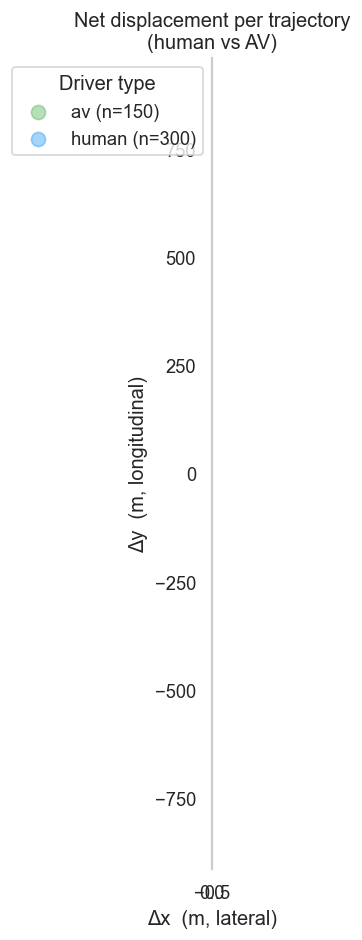

In [6]:
# --- 5a. Net displacement: delta_x vs delta_y ---
CLIP = 1.0
palette = {'human': '#2196F3', 'av': '#4CAF50'}

fig, ax = plt.subplots(figsize=(8, 8))
for dtype, grp in df.groupby('driver_type'):
    ax.scatter(grp['delta_x'], grp['delta_y'],
               s=8, alpha=0.4, color=palette[dtype], label=f'{dtype} (n={len(grp):,})')

xlim = (np.percentile(df['delta_x'], CLIP), np.percentile(df['delta_x'], 100 - CLIP))
ylim = (np.percentile(df['delta_y'], CLIP), np.percentile(df['delta_y'], 100 - CLIP))
ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
ax.axvline(0, color='k', linewidth=0.6, linestyle='--')
ax.set(xlabel='Δx  (m, lateral)', ylabel='Δy  (m, longitudinal)',
       title='Net displacement per trajectory\n(human vs AV)',
       aspect='equal', xlim=xlim, ylim=ylim)
ax.legend(markerscale=3, title='Driver type')
plt.tight_layout()
plt.show()

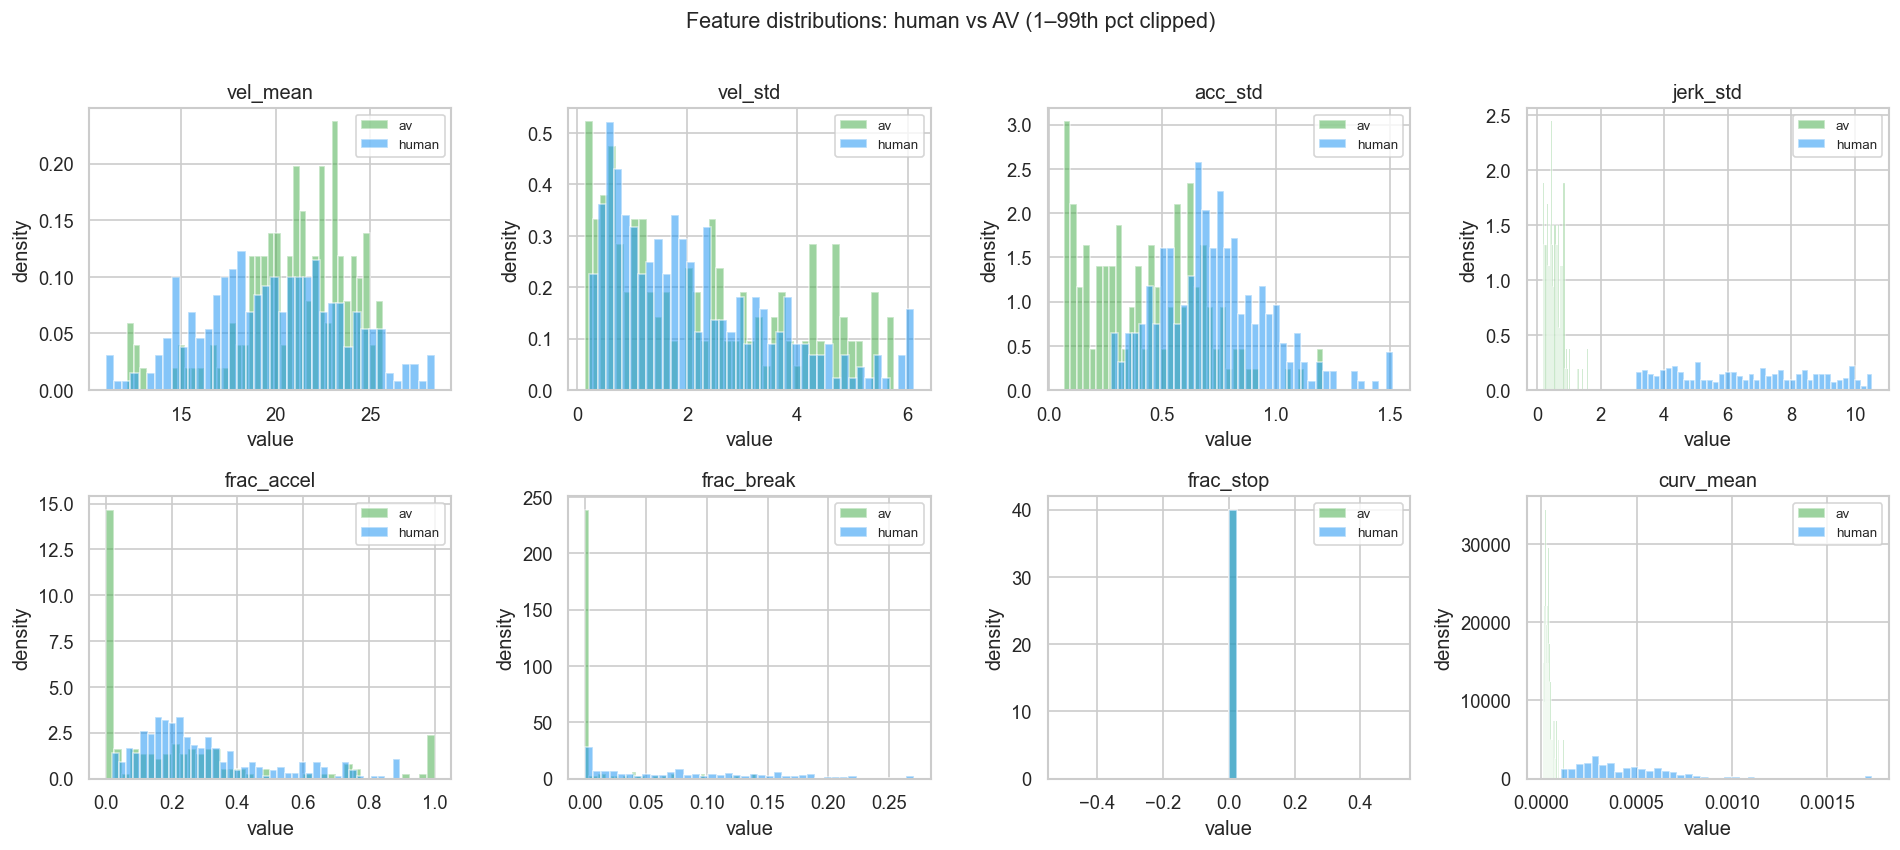

In [7]:
# --- 5b. Histogram grid for key discriminating features ----------------------
HIST_FEATS = ['vel_mean', 'vel_std', 'acc_std', 'jerk_std',
              'frac_accel', 'frac_break', 'frac_stop', 'curv_mean']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feat in zip(axes.flat, HIST_FEATS):
    for dtype, grp in df.groupby('driver_type'):
        vals = grp[feat].dropna()
        lo, hi = np.percentile(vals, 1), np.percentile(vals, 99)
        ax.hist(vals.clip(lo, hi), bins=40, alpha=0.55,
                color=palette[dtype], label=dtype, density=True)
    ax.set(title=feat, xlabel='value', ylabel='density')
    ax.legend(fontsize=8)

plt.suptitle('Feature distributions: human vs AV (1–99th pct clipped)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

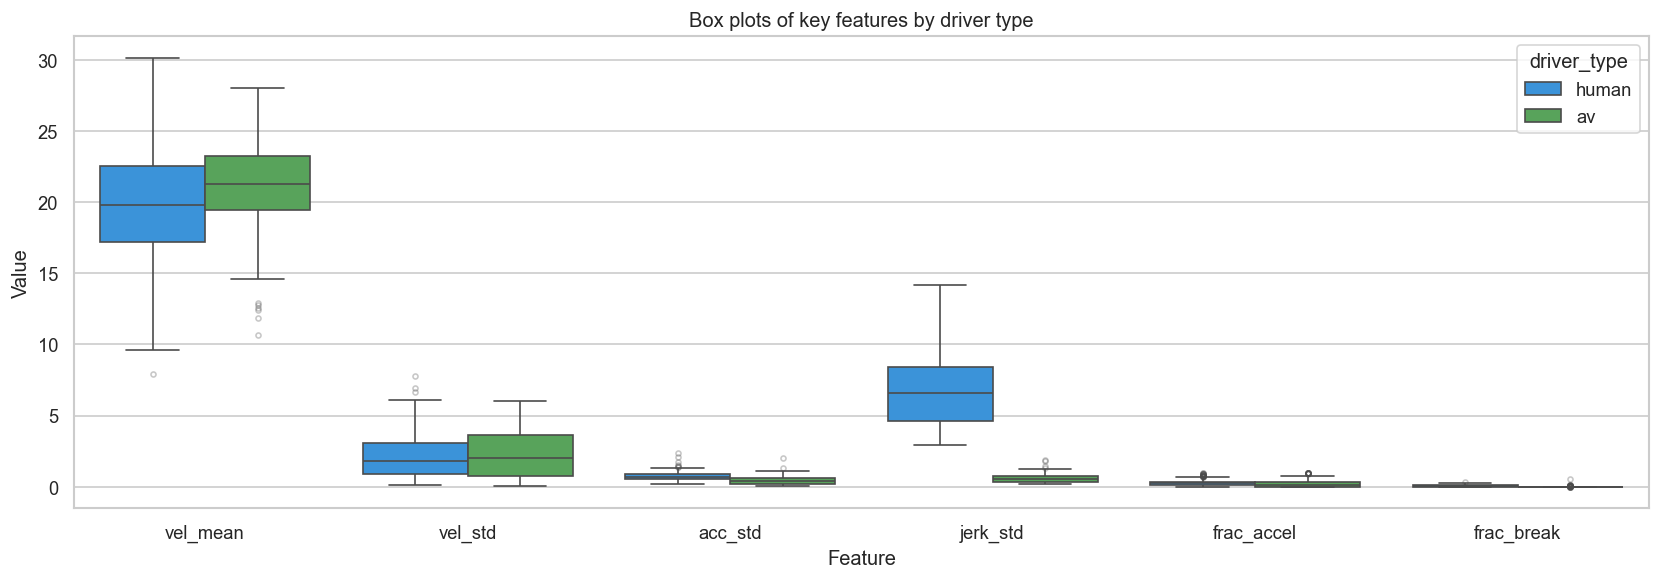

In [8]:
# --- 5c. Box plots ---
BOX_FEATS = ['vel_mean', 'vel_std', 'acc_std', 'jerk_std', 'frac_accel', 'frac_break']
melt = df[BOX_FEATS + ['driver_type']].melt(id_vars='driver_type', var_name='feature', value_name='value')

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=melt, x='feature', y='value', hue='driver_type',
            palette=palette, flierprops={'marker': '.', 'alpha': 0.3}, ax=ax)
ax.set(title='Box plots of key features by driver type', xlabel='Feature', ylabel='Value')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

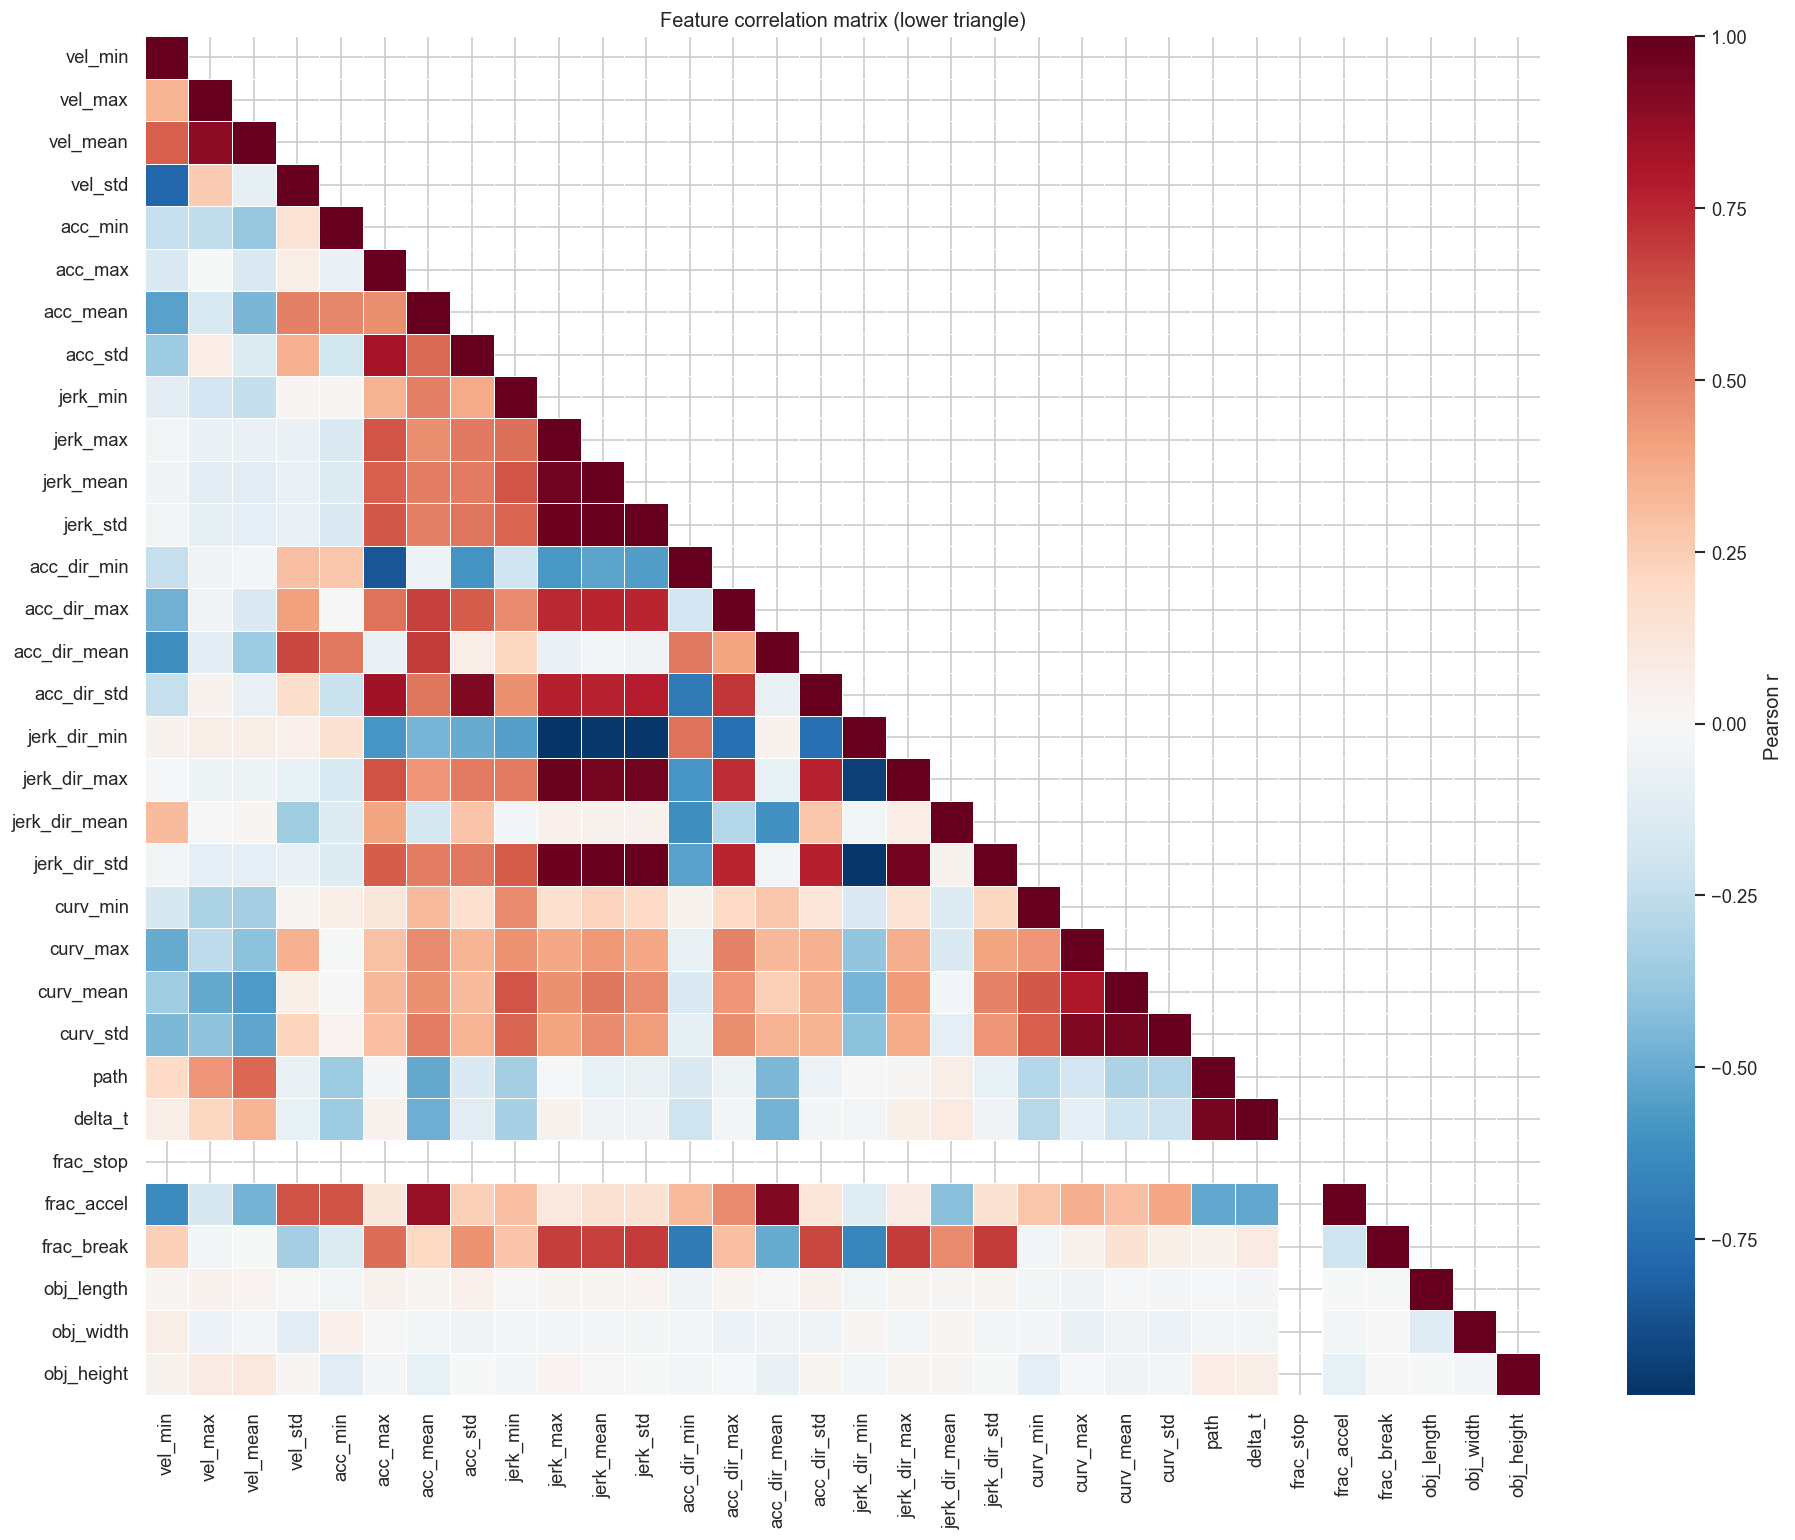

Top 10 most positively correlated pairs:
vel_min        vel_min          1.0
jerk_dir_mean  jerk_dir_mean    1.0
jerk_min       jerk_min         1.0
jerk_max       jerk_max         1.0
jerk_mean      jerk_mean        1.0
jerk_std       jerk_std         1.0
acc_dir_min    acc_dir_min      1.0
acc_dir_max    acc_dir_max      1.0
acc_dir_mean   acc_dir_mean     1.0
acc_dir_std    acc_dir_std      1.0


In [9]:
# --- Correlation matrix on active features (magnitude only) ------------------
corr = df[active_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, linewidths=0.3,
            annot=False, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set(title='Feature correlation matrix (lower triangle)', )
plt.tight_layout()
plt.show()

# Top 10 most-correlated pairs
corr_unstacked = corr.where(~mask).stack().sort_values(ascending=False)
print('Top 10 most positively correlated pairs:')
print(corr_unstacked.head(10).to_string())

## 7. Statistical Testing: Human vs AV Feature Differences

In [10]:
# --- Welch t-test for each feature, with Bonferroni correction ----------------
human = df[df['driver_type'] == 'human']
av    = df[df['driver_type'] == 'av']

results = []
for feat in active_cols:
    h_vals = human[feat].dropna()
    a_vals = av[feat].dropna()
    t_stat, p_val = stats.ttest_ind(h_vals, a_vals, equal_var=False)
    results.append(dict(
        feature     = feat,
        human_mean  = h_vals.mean(),
        av_mean     = a_vals.mean(),
        diff        = h_vals.mean() - a_vals.mean(),
        t_stat      = t_stat,
        p_value     = p_val,
    ))

ttest_df = pd.DataFrame(results)
ttest_df['p_bonferroni'] = np.minimum(ttest_df['p_value'] * len(active_cols), 1.0)
ttest_df['significant']  = ttest_df['p_bonferroni'] < 0.05
ttest_df = ttest_df.sort_values('p_bonferroni')

print(f'{ttest_df["significant"].sum()}/{len(ttest_df)} features significantly different (Bonferroni α=0.05):')
ttest_df[ttest_df['significant']][['feature','human_mean','av_mean','diff','p_bonferroni']].round(4).style \
    .background_gradient(cmap='RdYlGn_r', subset=['p_bonferroni'])

20/32 features significantly different (Bonferroni α=0.05):


,feature,human_mean,av_mean,diff,p_bonferroni
10,jerk_mean,9.589900,0.765400,8.824500,0.000000
19,jerk_dir_std,11.396500,0.931000,10.465500,0.000000
11,jerk_std,6.630900,0.572400,6.058500,0.000000
9,jerk_max,33.660300,3.274500,30.385800,0.000000
16,jerk_dir_min,-31.085800,-2.401300,-28.684500,0.000000
17,jerk_dir_max,30.932200,3.085800,27.846300,0.000000
13,acc_dir_max,3.267000,1.350700,1.916400,0.000000
22,curv_mean,0.000500,0.000000,0.000400,0.000000
8,jerk_min,0.506600,0.033400,0.473200,0.000000
15,acc_dir_std,1.044700,0.462000,0.582700,0.000000


/var/folders/d9/vp7jkvm979jc2_fkp1g0jxzm0000gn/T/ipykernel_58556/1887514402.py:23: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/d9/vp7jkvm979jc2_fkp1g0jxzm0000gn/T/ipykernel_58556/1887514402.py:23: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/dmitriikhitrin/anaconda3/envs/dry-dock/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dmitriikhitrin/anaconda3/envs/dry-dock/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


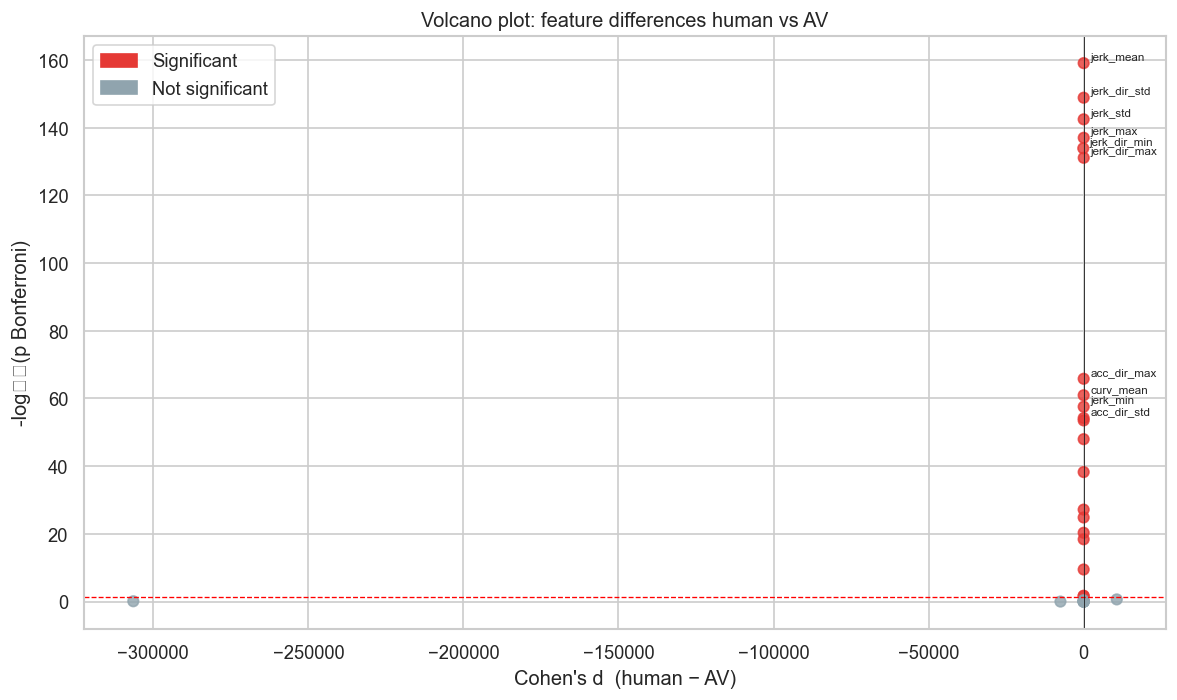

In [11]:
# --- Volcano plot: effect size vs significance --------------------------------
ttest_df['log10_p']  = -np.log10(ttest_df['p_bonferroni'].clip(1e-300))
# Standardised mean difference (Cohen's d approximation)
ttest_df['cohens_d'] = ttest_df['diff'] / (
    0.5 * (human[active_cols].std() + av[active_cols].std())
).values

fig, ax = plt.subplots(figsize=(10, 6))
colors = ttest_df['significant'].map({True: '#E53935', False: '#90A4AE'})
ax.scatter(ttest_df['cohens_d'], ttest_df['log10_p'], c=colors, s=40, alpha=0.8)

for _, row in ttest_df[ttest_df['significant']].head(10).iterrows():
    ax.annotate(row['feature'], (row['cohens_d'], row['log10_p']),
                fontsize=7, xytext=(4, 2), textcoords='offset points')

ax.axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=0.8, label='α=0.05')
ax.axvline(0, color='k', linewidth=0.5)
ax.set(xlabel="Cohen's d  (human − AV)", ylabel='-log₁₀(p Bonferroni)',
       title='Volcano plot: feature differences human vs AV')
handles = [mpatches.Patch(color='#E53935', label='Significant'),
           mpatches.Patch(color='#90A4AE', label='Not significant')]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

## 8. Apply PCA

In [12]:
# Fit full PCA to inspect variance spectrum
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90   = int(np.argmax(cumvar >= 0.90)) + 1
n_95   = int(np.argmax(cumvar >= 0.95)) + 1
print(f'Components to explain 90% variance: {n_90}')
print(f'Components to explain 95% variance: {n_95}')

N_COMPONENTS = n_95
pca    = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca  = pca.fit_transform(X_scaled)
print(f'PCA output shape: {X_pca.shape}')

Components to explain 90% variance: 9
Components to explain 95% variance: 12
PCA output shape: (450, 12)


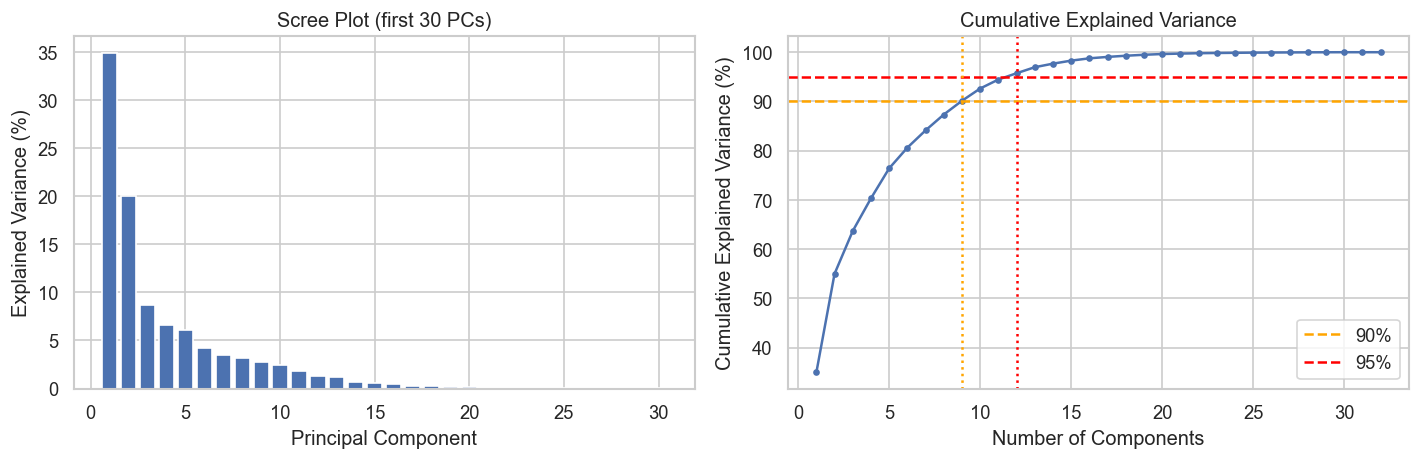

In [13]:
# --- Scree plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_show = min(30, len(pca_full.explained_variance_ratio_))
axes[0].bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100)
axes[0].set(xlabel='Principal Component', ylabel='Explained Variance (%)',
            title='Scree Plot (first 30 PCs)')

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o', markersize=3)
axes[1].axhline(90, color='orange', linestyle='--', label='90%')
axes[1].axhline(95, color='red',    linestyle='--', label='95%')
axes[1].axvline(n_90, color='orange', linestyle=':')
axes[1].axvline(n_95, color='red',    linestyle=':')
axes[1].set(xlabel='Number of Components', ylabel='Cumulative Explained Variance (%)',
            title='Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Visualise PCA Results

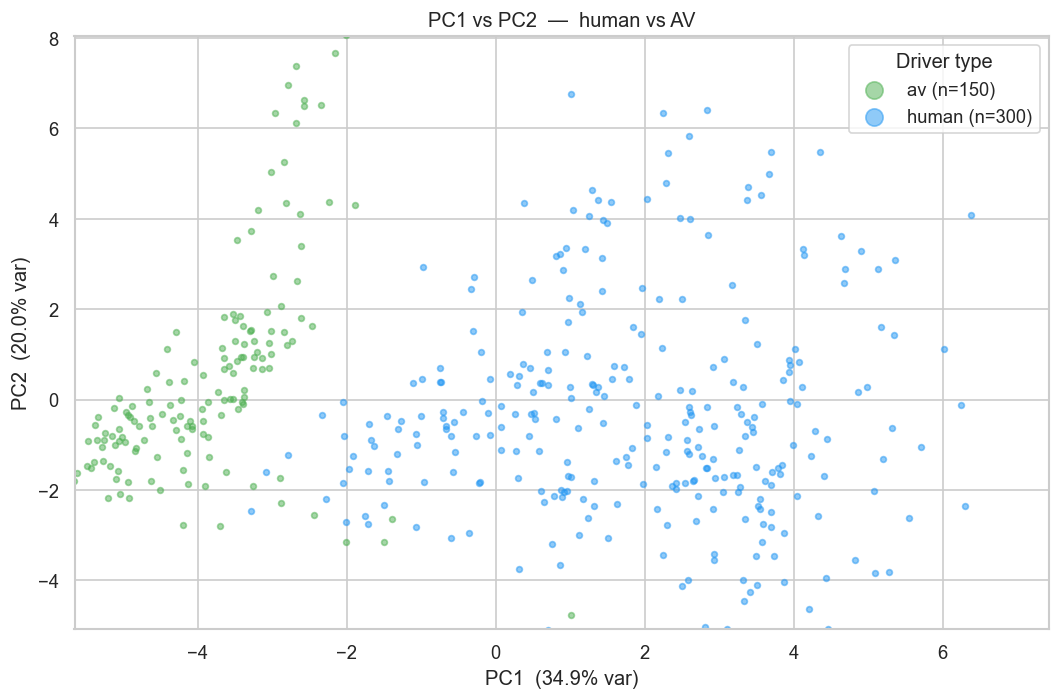

In [14]:
# --- PC scatter: colour by driver type ---
# ── CONFIG ────────────────────────────────────────────────────────────────────
PC_X    = 1
PC_Y    = 2
CLIP_PCT = 0.5

assert 1 <= PC_X <= pca.n_components_, f'PC_X out of range 1–{pca.n_components_}'
assert 1 <= PC_Y <= pca.n_components_, f'PC_Y out of range 1–{pca.n_components_}'

plot_df = pd.DataFrame({
    f'PC{PC_X}': X_pca[:, PC_X - 1],
    f'PC{PC_Y}': X_pca[:, PC_Y - 1],
    'driver_type': labels,
})

xlim = (np.percentile(plot_df[f'PC{PC_X}'], CLIP_PCT), np.percentile(plot_df[f'PC{PC_X}'], 100 - CLIP_PCT))
ylim = (np.percentile(plot_df[f'PC{PC_Y}'], CLIP_PCT), np.percentile(plot_df[f'PC{PC_Y}'], 100 - CLIP_PCT))

var_x = pca.explained_variance_ratio_[PC_X - 1] * 100
var_y = pca.explained_variance_ratio_[PC_Y - 1] * 100

fig, ax = plt.subplots(figsize=(9, 6))
for dtype, grp in plot_df.groupby('driver_type'):
    ax.scatter(grp[f'PC{PC_X}'], grp[f'PC{PC_Y}'],
               s=12, alpha=0.5, color=palette[dtype], label=f'{dtype} (n={len(grp):,})')

ax.set(xlabel=f'PC{PC_X}  ({var_x:.1f}% var)',
       ylabel=f'PC{PC_Y}  ({var_y:.1f}% var)',
       title=f'PC{PC_X} vs PC{PC_Y}  —  human vs AV',
       xlim=xlim, ylim=ylim)
ax.legend(markerscale=3, title='Driver type')
plt.tight_layout()
plt.show()

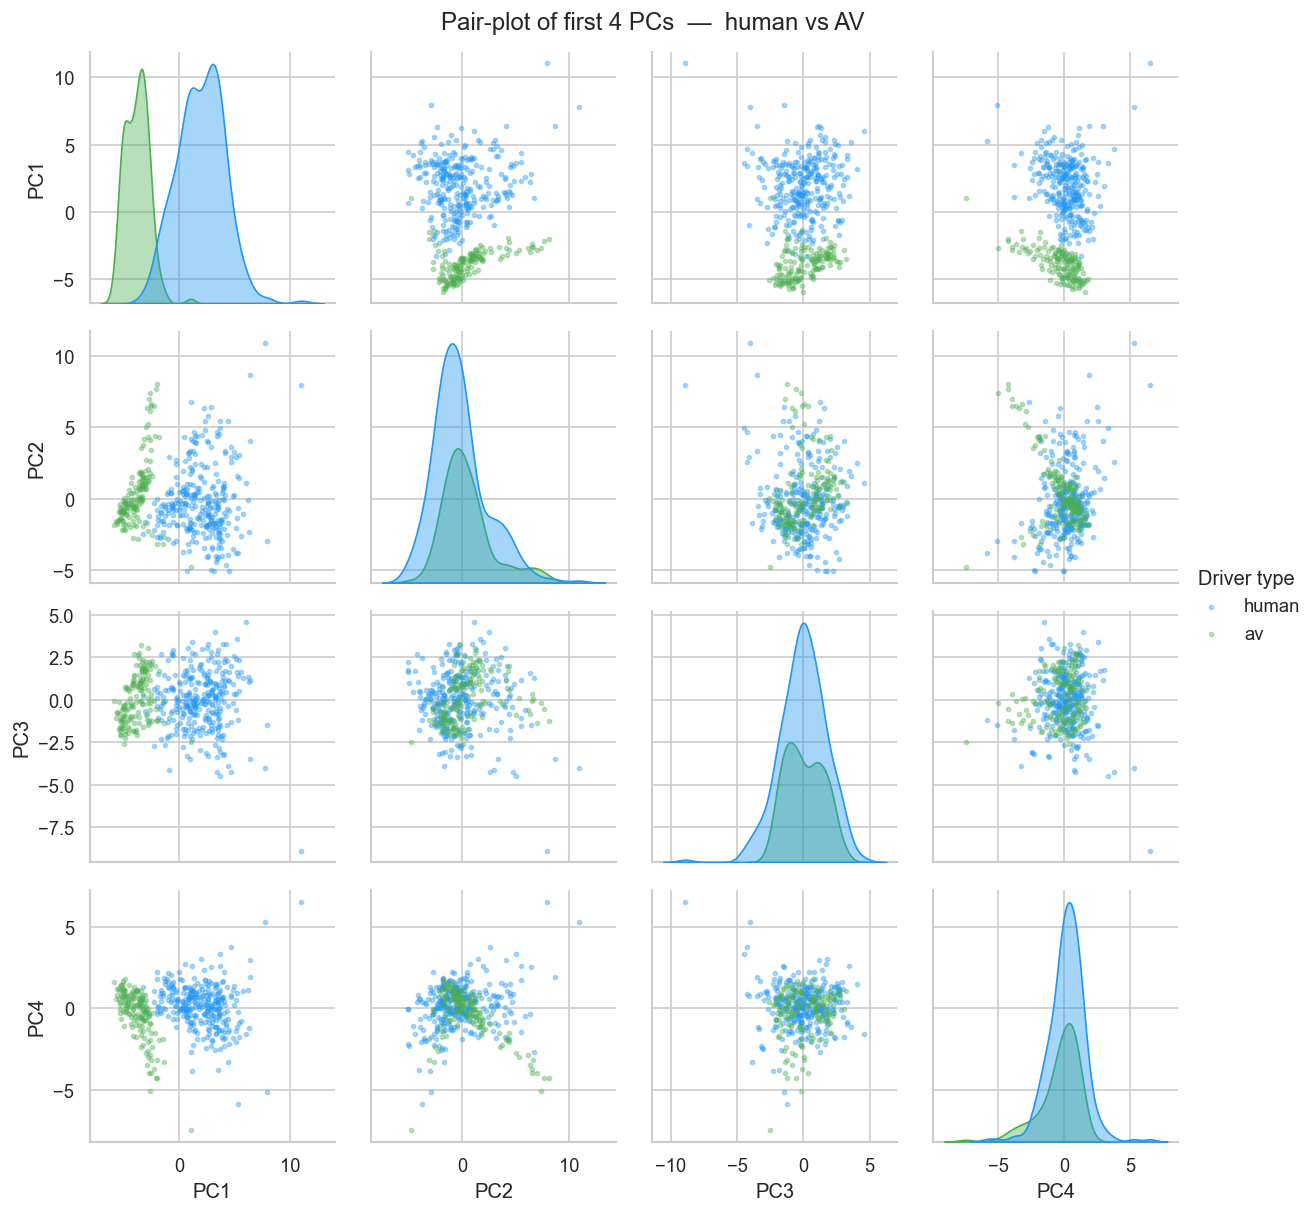

In [15]:
# --- Pair-plot for first 4 PCs -----------------------------------------------
n_pair = min(4, pca.n_components_)
pair_df = pd.DataFrame(X_pca[:, :n_pair],
                       columns=[f'PC{i+1}' for i in range(n_pair)])
pair_df['driver_type'] = labels

g = sns.PairGrid(pair_df, hue='driver_type', palette=palette, diag_sharey=False)
g.map_diag(sns.kdeplot, fill=True, alpha=0.4)
g.map_offdiag(plt.scatter, s=6, alpha=0.35)
g.add_legend(title='Driver type')
g.figure.suptitle('Pair-plot of first 4 PCs  —  human vs AV', y=1.01)
plt.show()

## 10. Interpret Principal Components

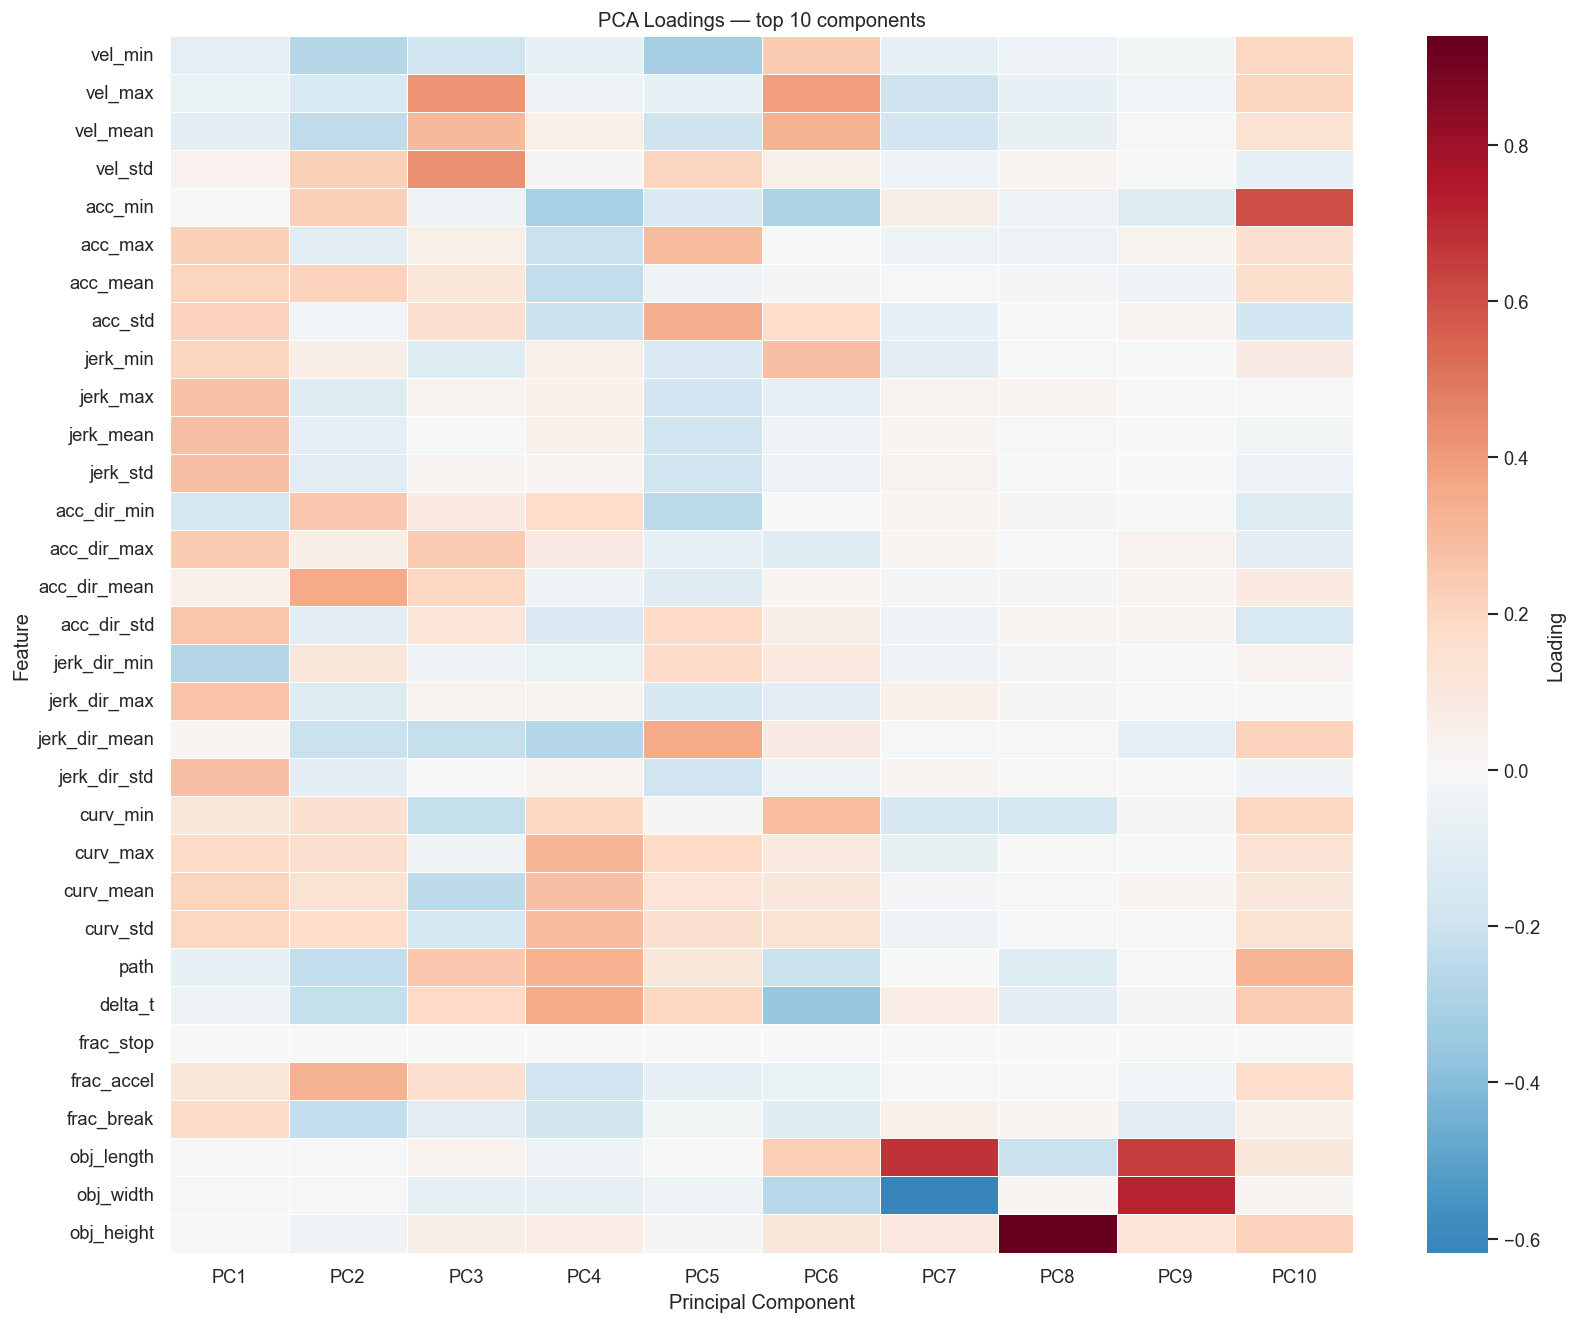

In [16]:
# --- Loadings heatmap (top PCs) -----------------------------------------------
n_pc_show = min(10, pca.n_components_)
loadings  = pd.DataFrame(
    pca.components_[:n_pc_show].T,
    index=active_cols,
    columns=[f'PC{i+1}' for i in range(n_pc_show)]
)

fig, ax = plt.subplots(figsize=(14, max(6, len(active_cols) * 0.35)))
sns.heatmap(loadings, cmap='RdBu_r', center=0, linewidths=0.3,
            cbar_kws={'label': 'Loading'}, ax=ax)
ax.set(title=f'PCA Loadings — top {n_pc_show} components',
       xlabel='Principal Component', ylabel='Feature')
plt.tight_layout()
plt.show()

In [17]:
# --- Top contributing features per PC (text summary) -------------------------
N_TOP = min(8, len(active_cols))
for pc_idx in range(min(5, pca.n_components_)):
    top  = loadings[f'PC{pc_idx+1}'].abs().nlargest(N_TOP)
    var  = pca.explained_variance_ratio_[pc_idx] * 100
    print(f'\nPC{pc_idx+1}  ({var:.1f}% variance) — top {N_TOP} features:')
    for feat in top.index:
        loading = loadings[f'PC{pc_idx+1}'][feat]
        bar  = '█' * int(abs(loading) * 30)
        sign = '+' if loading > 0 else '-'
        print(f'  {sign}{bar:<30}  {feat}  ({loading:+.3f})')


PC1  (34.9% variance) — top 8 features:
  +████████                        jerk_mean  (+0.281)
  +████████                        jerk_dir_std  (+0.280)
  +████████                        jerk_std  (+0.279)
  +████████                        jerk_max  (+0.273)
  -████████                        jerk_dir_min  (-0.270)
  +████████                        jerk_dir_max  (+0.268)
  +███████                         acc_dir_std  (+0.260)
  +███████                         acc_dir_max  (+0.249)

PC2  (20.0% variance) — top 8 features:
  +██████████                      acc_dir_mean  (+0.355)
  +█████████                       frac_accel  (+0.326)
  -████████                        vel_min  (-0.271)
  +███████                         acc_dir_min  (+0.257)
  -███████                         vel_mean  (-0.236)
  -███████                         path  (-0.234)
  -██████                          frac_break  (-0.230)
  +██████                          vel_std  (+0.227)

PC3  (8.7% variance) — top 8 

In [18]:
# --- Per-driver-type mean PC scores (centroid separation) --------------------
n_c   = min(5, pca.n_components_)
pc_df = pd.DataFrame(X_pca[:, :n_c],
                     columns=[f'PC{i+1}' for i in range(n_c)])
pc_df['driver_type'] = labels

centroids = pc_df.groupby('driver_type').mean().round(3)
print('Mean PC scores by driver type (PC1–PC5):')
centroids.style.background_gradient(cmap='RdBu_r', axis=None)

Mean PC scores by driver type (PC1–PC5):


,PC1,PC2,PC3,PC4,PC5
driver_type,,,,,
av,-3.858000,0.439000,0.077000,-0.347000,0.322000
human,1.929000,-0.220000,-0.039000,0.173000,-0.161000


## 11. Outlier Detection with Isolation Forest
Anomalous trajectories within the synthetic dataset — vehicles that deviate from the typical human *or* AV behaviour.

In [19]:
# ── CONFIG ─────────────────────────────────────────────────────────────────────
OUTLIER_CONTAMINATION = 0.05

iso            = IsolationForest(contamination=OUTLIER_CONTAMINATION, random_state=42, n_jobs=-1)
outlier_pred   = iso.fit_predict(X_pca)
outlier_scores = iso.score_samples(X_pca)

result_df = df.reset_index(drop=True).copy()
result_df['outlier']       = outlier_pred == -1
result_df['anomaly_score'] = outlier_scores

n_out = result_df['outlier'].sum()
print(f'Outliers detected : {n_out} / {len(result_df)}  ({n_out/len(result_df)*100:.1f}%)')
print('\nOutlier count by driver type:')
print(
    result_df.groupby('driver_type')[['outlier']].sum()
    .join(result_df.groupby('driver_type').size().rename('total'))
    .assign(pct=lambda d: (d['outlier'] / d['total'] * 100).round(1))
    .to_string()
)

Outliers detected : 23 / 450  (5.1%)

Outlier count by driver type:
             outlier  total  pct
driver_type                     
av                 9    150  6.0
human             14    300  4.7


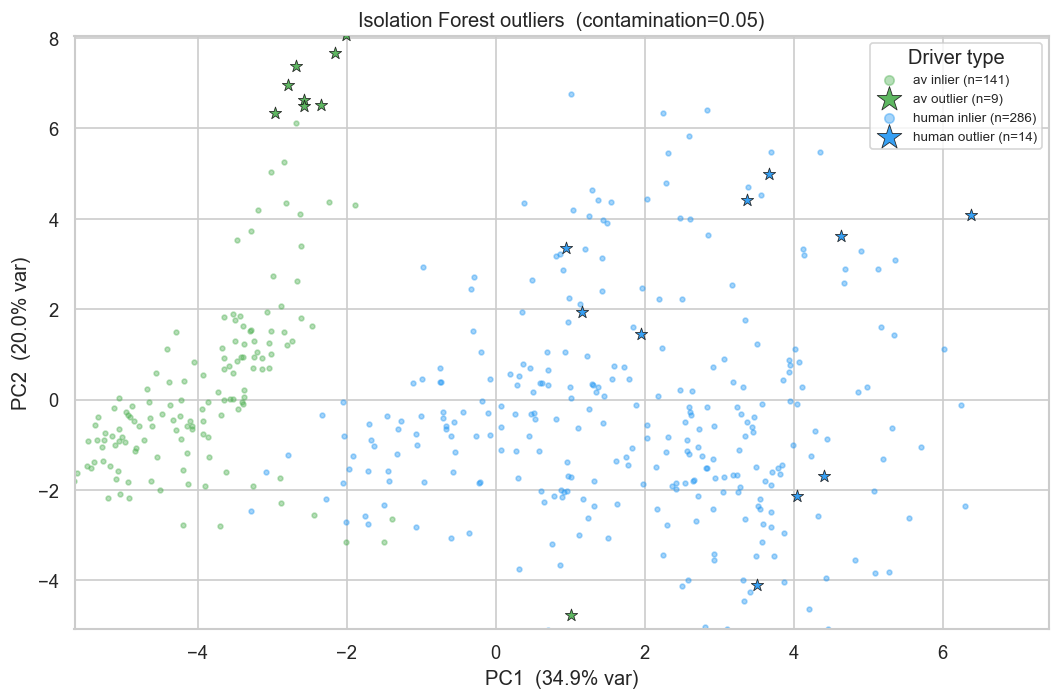

In [20]:
# --- PC scatter with outliers highlighted ------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

for dtype, grp_idx in result_df.groupby('driver_type').groups.items():
    grp   = result_df.loc[grp_idx]
    inliers  = grp[~grp['outlier']]
    outliers = grp[grp['outlier']]
    ax.scatter(X_pca[inliers.index,  PC_X - 1], X_pca[inliers.index,  PC_Y - 1],
               s=8,  alpha=0.4, color=palette[dtype], label=f'{dtype} inlier (n={len(inliers):,})')
    ax.scatter(X_pca[outliers.index, PC_X - 1], X_pca[outliers.index, PC_Y - 1],
               s=60, alpha=0.9, marker='*', color=palette[dtype], edgecolors='k',
               linewidths=0.5, label=f'{dtype} outlier (n={len(outliers)})', zorder=5)

ax.set(xlabel=f'PC{PC_X}  ({var_x:.1f}% var)', ylabel=f'PC{PC_Y}  ({var_y:.1f}% var)',
       title=f'Isolation Forest outliers  (contamination={OUTLIER_CONTAMINATION})',
       xlim=xlim, ylim=ylim)
ax.legend(markerscale=2, title='Driver type', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# --- Top most anomalous trajectories -----------------------------------------
N_SHOW       = 15
display_cols = [
    'object_id', 'driver_type', 'anomaly_score',
    'vel_mean', 'vel_max', 'vel_std',
    'acc_max', 'acc_dir_min', 'acc_dir_max',
    'jerk_max', 'curv_max',
    'path', 'delta_t', 'frac_stop', 'frac_accel', 'frac_break',
]
display_cols = [c for c in display_cols if c in result_df.columns]

top_outliers = result_df.nsmallest(N_SHOW, 'anomaly_score')[display_cols].round(3)
print(f'Top {N_SHOW} most anomalous trajectories:')
top_outliers.style \
    .background_gradient(cmap='Reds_r', subset=['anomaly_score']) \
    .background_gradient(cmap='YlOrRd', subset=[c for c in ['vel_max', 'acc_max', 'jerk_max'] if c in display_cols])